# Optimization

This notebook studies how derivatives help locate maximum and minimum values, why optimization matters in machine learning, and how derivative information guides iterative search methods.

## Video 1 — Derivatives and optimization

**Optimization** means finding an input where a function reaches a maximum or minimum value.

In machine learning, a model is evaluated using an **error**, **loss**, or **objective** function. This function assigns a number that measures how poorly the model fits the chosen goal. Training often means adjusting the model's parameters to make that number as small as possible.

Derivatives help because they describe which direction makes the objective increase or decrease.

### Searching for the coldest place on a sauna bench

Imagine sitting on a sauna bench with a thermometer:

1. At the initial position, the temperature is $85$ degrees Celsius.
2. Moving left produces a reading of $90$ degrees Celsius, so that direction is hotter.
3. Moving right produces a reading of $80$ degrees Celsius, so that direction is colder.
4. Continuing toward lower readings eventually reaches a position where moving either way makes the temperature rise.

That final position is a minimum of the temperature function: locally, no nearby position is colder.

### What the derivative says

Let $T(x)$ be the temperature at position $x$ along the bench.

- If $T'(x)<0$, the graph slopes downward as $x$ increases, so moving right decreases the temperature.
- If $T'(x)>0$, the graph slopes upward as $x$ increases, so moving left decreases the temperature.
- At a smooth interior minimum, $T'(x)=0$ because the tangent is horizontal.

Thus, points satisfying

$$
T'(x)=0
$$

are **candidates** for maxima or minima. A zero derivative alone does not prove that a point is an optimum.

### Simple and more complicated temperature curves

The left plot reconstructs the lecture's $85$, $90$, and $80$ degree readings using schematic bench positions. The curve and its minimum temperature are illustrative because their exact values are not supplied in the transcript.

The right plot is also schematic. It shows why a complicated function may have several zero-derivative candidates that must be classified.

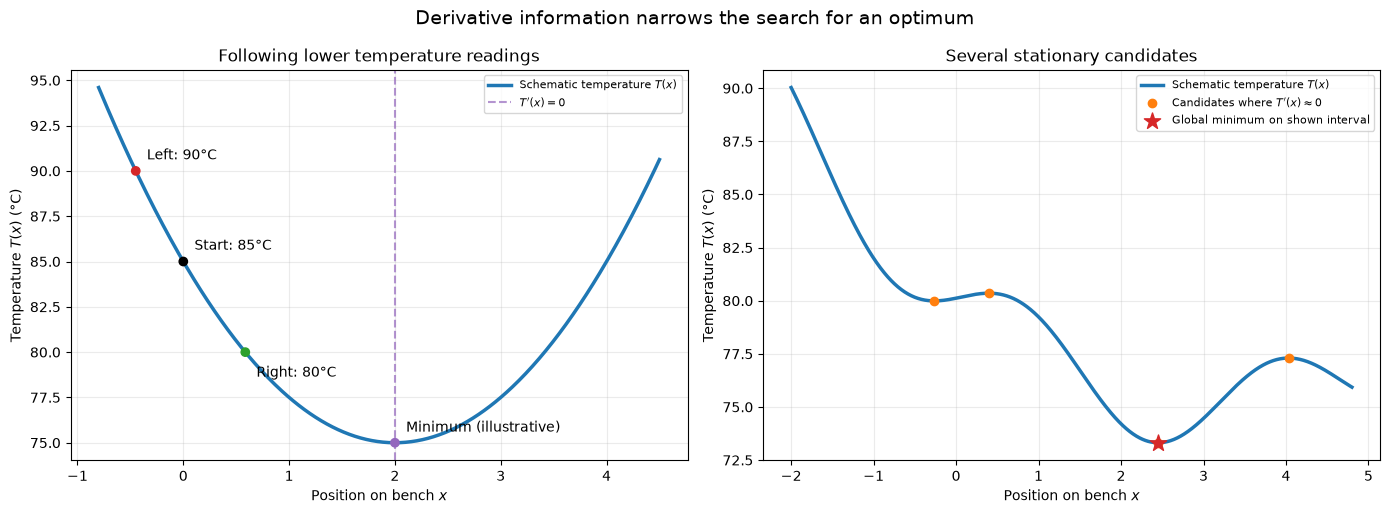

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

simple_positions: np.ndarray = np.linspace(-0.8, 4.5, 500)
simple_temperatures: np.ndarray = 75.0 + 2.5 * (simple_positions - 2.0) ** 2
initial_position: float = 0.0
left_trial_position: float = 2.0 - float(np.sqrt(6.0))
right_trial_position: float = 2.0 - float(np.sqrt(2.0))
minimum_position: float = 2.0

complex_positions: np.ndarray = np.linspace(-2.0, 4.8, 1000)
complex_temperatures: np.ndarray = (
    75.0 + 0.5 * (complex_positions - 3.2) ** 2 + 2.0 * np.sin(2.0 * complex_positions)
)
complex_derivatives: np.ndarray = complex_positions - 3.2 + 4.0 * np.cos(2.0 * complex_positions)
critical_indices: np.ndarray = np.flatnonzero(
    np.sign(complex_derivatives[:-1]) != np.sign(complex_derivatives[1:])
)
global_minimum_index: int = int(np.argmin(complex_temperatures))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].plot(simple_positions, simple_temperatures, color="tab:blue", linewidth=2.5,
             label="Schematic temperature $T(x)$")
axes[0].scatter(
    [initial_position, left_trial_position, right_trial_position, minimum_position],
    [85.0, 90.0, 80.0, 75.0],
    color=["black", "tab:red", "tab:green", "tab:purple"],
    zorder=3,
)
axes[0].annotate("Start: $85°$C", (initial_position, 85.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].annotate("Left: $90°$C", (left_trial_position, 90.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].annotate("Right: $80°$C", (right_trial_position, 80.0), xytext=(8, -18),
                 textcoords="offset points")
axes[0].annotate("Minimum (illustrative)", (minimum_position, 75.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].axvline(minimum_position, color="tab:purple", linestyle="--", alpha=0.7,
                label="$T'(x)=0$")
axes[0].set(title="Following lower temperature readings", xlabel="Position on bench $x$",
            ylabel="Temperature $T(x)$ (°C)")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(complex_positions, complex_temperatures, color="tab:blue", linewidth=2.5,
             label="Schematic temperature $T(x)$")
axes[1].scatter(complex_positions[critical_indices], complex_temperatures[critical_indices],
                color="tab:orange", zorder=3, label="Candidates where $T'(x)\\approx0$")
axes[1].scatter([complex_positions[global_minimum_index]],
                [complex_temperatures[global_minimum_index]], color="tab:red", marker="*",
                s=150, zorder=4, label="Global minimum on shown interval")
axes[1].set(title="Several stationary candidates", xlabel="Position on bench $x$",
            ylabel="Temperature $T(x)$ (°C)")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle("Derivative information narrows the search for an optimum", fontsize=14)
fig.tight_layout()
plt.show()

### Local and global minima

A **local minimum** is a point whose function value is no larger than the values at nearby points. A **global minimum** is a point whose function value is no larger than the value at every other point in the domain.

A complicated function can contain several stationary points where

$$
f'(x)=0.
$$

They are candidates, not guaranteed minima. A stationary point could be:

- a local minimum;
- a local maximum;
- neither, such as a flat point where the function continues increasing.

To find the global minimum, the candidates must be evaluated and compared with every other type of candidate required by the domain.

### The condition behind the zero-slope rule

The precise result is:

> If $f$ is differentiable at an **interior** point $x^*$ and has a local maximum or minimum there, then $f'(x^*)=0$.

The conditions matter. An optimum can also occur:

- at an endpoint of a restricted interval;
- at a point where the derivative does not exist, such as the corner of $|x|$;
- at one of several points where the derivative is zero.

Therefore, solving $f'(x)=0$ finds important candidates, but it does not complete every optimization problem by itself.

### Takeaway

Derivatives turn optimization into a more focused search:

$$
\boxed{f'(x)=0}
$$

identifies stationary candidates for smooth interior maxima and minima. The derivative's sign also provides direction:

- $f'(x)<0$: increasing $x$ locally decreases $f$;
- $f'(x)>0$: decreasing $x$ locally decreases $f$;
- $f'(x)=0$: inspect and classify the point.

In machine learning, this idea is used to search for parameter values that minimize a chosen loss or objective function.

## Video 2 — Minimizing a squared connection cost

Consider choosing where to build a house that must connect to several power lines. Longer connections require more cable and are modeled as more expensive.

In this simplified problem, the cost of one connection is the square of its distance:

$$
\text{connection cost}=(\text{distance})^2.
$$

The goal is to place the house where the **total** cost of all connections is as small as possible.

### Why squared cost matters in machine learning

This connection cost has the same mathematical shape as **squared error**:

$$
\text{squared error}=(\text{prediction}-\text{target})^2.
$$

The difference between a prediction and its target is called the **error** or **residual**. Squaring it makes the result nonnegative and penalizes larger errors more strongly.

Squared error is commonly used to train linear regression models and also appears in some neural-network objectives. Learning to minimize a squared distance therefore prepares us to minimize machine-learning loss functions.

### Start with one power line

Let

- $x$ be the house's position along a one-dimensional coordinate line;
- $p$ be the power line's position.

The distance between them is $|x-p|$. Squaring removes the absolute value because

$$
|x-p|^2=(x-p)^2.
$$

Therefore, the connection cost is

$$
C(x)=(x-p)^2.
$$

If the power line is used as the origin, then $p=0$ and this becomes the transcript's simpler formula:

$$
C(x)=x^2.
$$

### The minimum occurs at the power line

Differentiate the cost:

$$
C'(x)=2(x-p).
$$

A smooth interior minimum must be among the points where the derivative is zero:

$$
\begin{aligned}
2(x-p)&=0, \\
x-p&=0, \\
x&=p.
\end{aligned}
$$

At this position, the distance and cost are both zero:

$$
C(p)=(p-p)^2=0.
$$

Because a square can never be negative, zero is the global minimum. With one power line, the least expensive location is directly beside that line.

### Visualizing the one-line cost

The power-line coordinate below is illustrative because the transcript does not assign it a numerical position. The horizontal distance from $x$ to $p$ becomes the height $(x-p)^2$ on the cost curve.

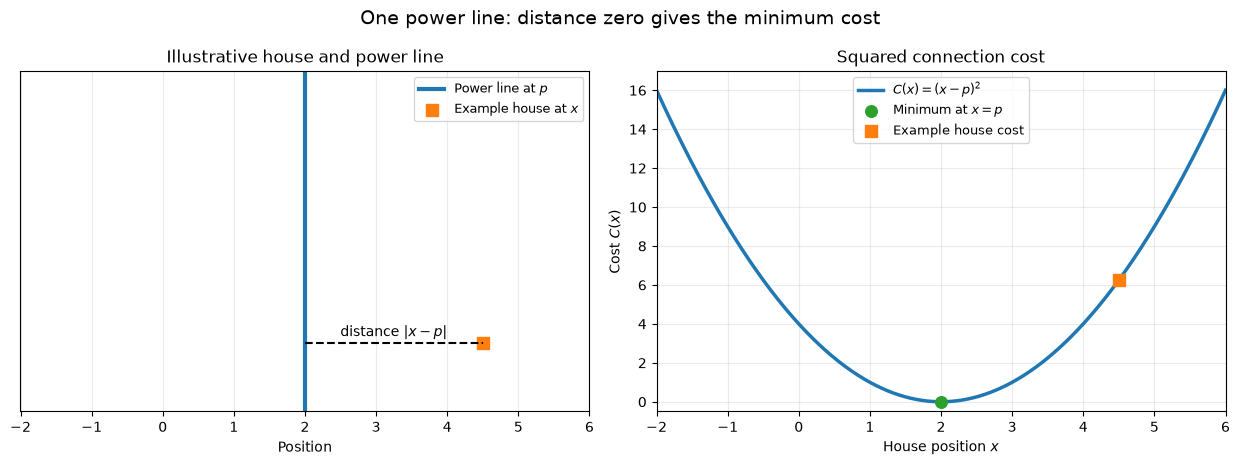

In [2]:
power_line_position: float = 2.0
house_positions: np.ndarray = np.linspace(-2.0, 6.0, 400)
connection_costs: np.ndarray = (house_positions - power_line_position) ** 2
example_house_position: float = 4.5
example_connection_cost: float = (example_house_position - power_line_position) ** 2

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))

axes[0].axvline(power_line_position, color="tab:blue", linewidth=3, label="Power line at $p$")
axes[0].scatter([example_house_position], [0], color="tab:orange", marker="s", s=75,
                label="Example house at $x$")
axes[0].annotate(
    "distance $|x-p|$",
    xy=((power_line_position + example_house_position) / 2, 0.03),
    ha="center",
)
axes[0].plot([power_line_position, example_house_position], [0, 0], color="black",
             linestyle="--")
axes[0].set(title="Illustrative house and power line", xlabel="Position", ylabel="",
            xlim=(-2, 6), ylim=(-0.3, 1.2), yticks=[])
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].plot(house_positions, connection_costs, color="tab:blue", linewidth=2.5,
             label="$C(x)=(x-p)^2$")
axes[1].scatter([power_line_position], [0], color="tab:green", s=70, zorder=3,
                label="Minimum at $x=p$")
axes[1].scatter([example_house_position], [example_connection_cost], color="tab:orange",
                marker="s", s=65, zorder=3, label="Example house cost")
axes[1].set(title="Squared connection cost", xlabel="House position $x$",
            ylabel="Cost $C(x)$", xlim=(-2, 6), ylim=(-0.5, 17))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

fig.suptitle("One power line: distance zero gives the minimum cost", fontsize=14)
fig.tight_layout()
plt.show()

### Setting up the multi-line problem

If three power lines lie at positions $p_1$, $p_2$, and $p_3$, then the total squared connection cost is

$$
C(x)
=
(x-p_1)^2+(x-p_2)^2+(x-p_3)^2.
$$

Each line contributes one squared-distance term. This has the same sum-of-squares structure as a machine-learning objective with several data points.

The next step is to differentiate this total cost and determine which house position minimizes it.

## Video 3 — Optimizing the location between two power lines

Place two power lines on a one-dimensional coordinate line:

- the blue power line is at position $a$;
- the orange power line is at position $b$;
- the house is at position $x$.

Assume $a<b$. When the house lies between the lines, its distances are

$$
x-a
\qquad\text{and}\qquad
b-x.
$$

The goal is to choose $x$ so that the total squared connection cost is as small as possible.

### Squaring removes the direction

The blue connection costs

$$
(x-a)^2,
$$

and the orange connection costs

$$
(b-x)^2.
$$

Because $b-x=-(x-b)$ and squaring removes the sign,

$$
(b-x)^2=(x-b)^2.
$$

We can therefore write every squared distance in the consistent form $(x-\text{line position})^2$, even if the difference inside the parentheses is negative.

The total cost is

$$
\boxed{C(x)=(x-a)^2+(x-b)^2.}
$$

### Squared distances as square areas

A square with side length $|x-a|$ has area $(x-a)^2$, and a square with side length $|x-b|$ has area $(x-b)^2$. The total connection cost can therefore be visualized as the sum of these two square areas.

Moving too far left makes the orange square large. Moving too far right makes the blue square large. The balance occurs halfway between the power lines.

The following diagram uses illustrative positions $a=1$ and $b=7$ because the transcript supplies symbols but no numerical coordinates.

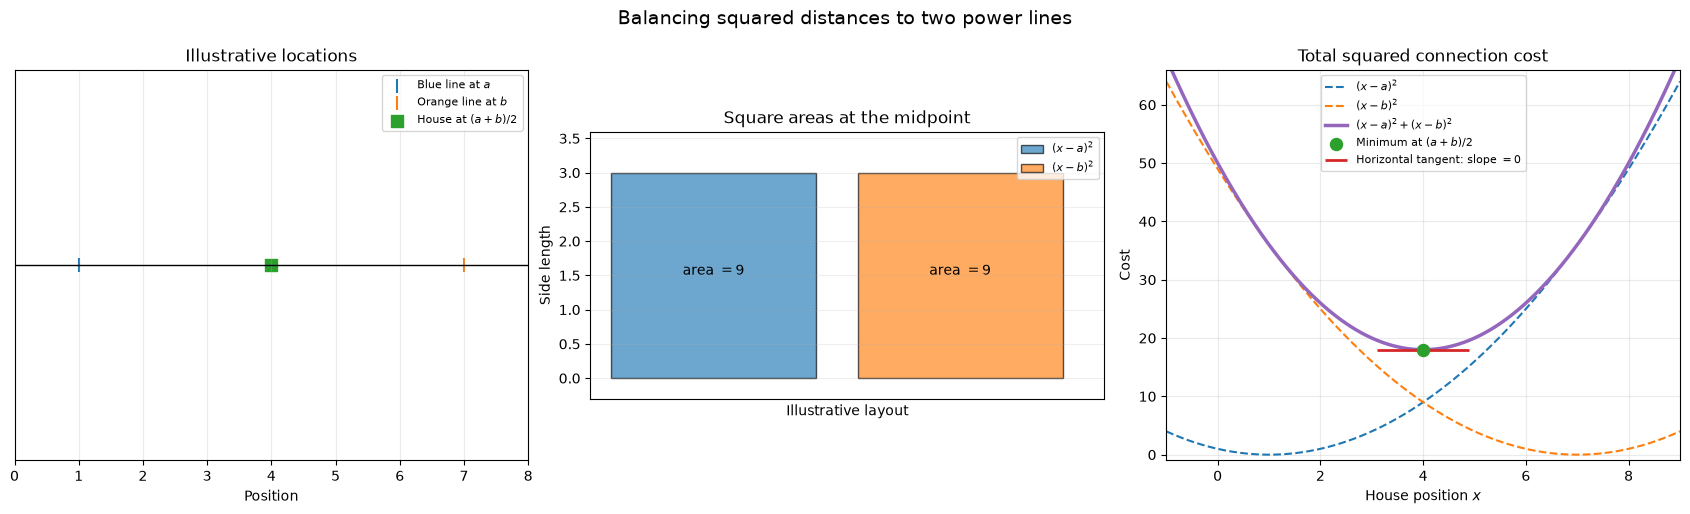

In [3]:
from matplotlib.patches import Rectangle

two_line_a: float = 1.0
two_line_b: float = 7.0
two_line_midpoint: float = (two_line_a + two_line_b) / 2.0
two_line_distance: float = two_line_midpoint - two_line_a
two_line_positions: np.ndarray = np.linspace(-1.0, 9.0, 500)
blue_costs: np.ndarray = (two_line_positions - two_line_a) ** 2
orange_costs: np.ndarray = (two_line_positions - two_line_b) ** 2
total_two_line_costs: np.ndarray = blue_costs + orange_costs
minimum_two_line_cost: float = 2.0 * two_line_distance**2

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

axes[0].axhline(0, color="black", linewidth=1)
axes[0].scatter([two_line_a], [0], color="tab:blue", s=100, marker="|",
                label="Blue line at $a$")
axes[0].scatter([two_line_b], [0], color="tab:orange", s=100, marker="|",
                label="Orange line at $b$")
axes[0].scatter([two_line_midpoint], [0], color="tab:green", s=85, marker="s",
                label="House at $(a+b)/2$")
axes[0].set(title="Illustrative locations", xlabel="Position", ylabel="", xlim=(0, 8),
            ylim=(-0.8, 0.8), yticks=[])
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(fontsize=8)

blue_square = Rectangle((0, 0), two_line_distance, two_line_distance,
                        facecolor="tab:blue", alpha=0.65, edgecolor="black",
                        label="$(x-a)^2$")
orange_square = Rectangle((two_line_distance + 0.6, 0), two_line_distance, two_line_distance,
                          facecolor="tab:orange", alpha=0.65, edgecolor="black",
                          label="$(x-b)^2$")
axes[1].add_patch(blue_square)
axes[1].add_patch(orange_square)
axes[1].annotate(rf"area $={two_line_distance**2:g}$", (1.5, 1.5), ha="center")
axes[1].annotate(rf"area $={two_line_distance**2:g}$", (5.1, 1.5), ha="center")
axes[1].set(
    title="Square areas at the midpoint",
    xlabel="Illustrative layout",
    ylabel="Side length",
    xlim=(-0.3, 7.2),
    ylim=(-0.3, 3.6),
    xticks=[],
)
axes[1].set_aspect("equal")
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)

axes[2].plot(two_line_positions, blue_costs, color="tab:blue", linestyle="--",
             label="$(x-a)^2$")
axes[2].plot(two_line_positions, orange_costs, color="tab:orange", linestyle="--",
             label="$(x-b)^2$")
axes[2].plot(two_line_positions, total_two_line_costs, color="tab:purple", linewidth=2.5,
             label="$(x-a)^2+(x-b)^2$")
axes[2].scatter([two_line_midpoint], [minimum_two_line_cost], color="tab:green", s=75,
                zorder=3, label="Minimum at $(a+b)/2$")
axes[2].hlines(minimum_two_line_cost, two_line_midpoint - 0.9,
               two_line_midpoint + 0.9, color="tab:red", linewidth=2,
               label="Horizontal tangent: slope $=0$")
axes[2].set(title="Total squared connection cost", xlabel="House position $x$",
            ylabel="Cost", xlim=(-1, 9), ylim=(-1, 66))
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

fig.suptitle("Balancing squared distances to two power lines", fontsize=14)
fig.tight_layout()
plt.show()

### Why the cost curve opens upward

Expand both squares:

$$
\begin{aligned}
C(x)
&=(x-a)^2+(x-b)^2 \\
&=(x^2-2ax+a^2)+(x^2-2bx+b^2) \\
&=2x^2-2(a+b)x+a^2+b^2.
\end{aligned}
$$

The coefficient of $x^2$ is $2$, which is positive. Therefore, the graph is an upward-opening parabola, and its horizontal-tangent point is its global minimum.

### Differentiate and solve

At the minimum of this upward-opening parabola, the tangent slope is zero. Following the course notation, differentiate the full cost expression and set it equal to zero:

$$
\frac{d}{dx}\left[(x-a)^2+(x-b)^2\right]=0.
$$

Using the chain rule gives

$$
2(x-a)+2(x-b)=0.
$$

Now simplify one step at a time:

$$
\begin{aligned}
2(x-a)+2(x-b)&=0, \\
(x-a)+(x-b)&=0, \\
2x-a-b&=0, \\
2x&=a+b, \\
x&=\frac{a+b}{2}.
\end{aligned}
$$

The first derivative line can be expanded to show the chain-rule factors explicitly:

$$
\begin{aligned}
\frac{d}{dx}\left[(x-a)^2+(x-b)^2\right]
&=2(x-a)\frac{d}{dx}(x-a)
 +2(x-b)\frac{d}{dx}(x-b) \\
&=2(x-a)(1)+2(x-b)(1) \\
&=2(x-a)+2(x-b).
\end{aligned}
$$

### Takeaway

The least-cost house position is

$$
\boxed{x=\frac{a+b}{2}.}
$$

This is exactly the midpoint of the two power lines. At the midpoint, the two distances are equal, so neither squared-distance term dominates the other.

The same strategy extends to more power lines:

1. add one squared-distance term for each line;
2. differentiate the total cost;
3. set the derivative equal to zero;
4. solve for the minimizing location.

## Video 4 — Three power lines and the mean

Add a third power line at position $c$. The three line positions and the house position are now

$$
a,\qquad b,\qquad c,\qquad\text{and}\qquad x.
$$

As before, the direction of each difference does not affect its square:

$$
(b-x)^2=(x-b)^2
\qquad\text{and}\qquad
(c-x)^2=(x-c)^2.
$$

We can therefore write all three distances in the consistent forms $x-a$, $x-b$, and $x-c$ before squaring them.

### The total squared connection cost

Each power line contributes one squared-distance term:

$$
\boxed{
C(x)=(x-a)^2+(x-b)^2+(x-c)^2.
}
$$

The same cost can be visualized as the total area of three squares whose side lengths are $|x-a|$, $|x-b|$, and $|x-c|$.

The goal is to minimize the **sum** of those areas, not necessarily to make the three individual areas equal.

### Square areas and shifted parabolas

Each term is also an upward-opening parabola:

- $(x-a)^2$ has its minimum above $x=a$;
- $(x-b)^2$ has its minimum above $x=b$;
- $(x-c)^2$ has its minimum above $x=c$.

At any house position $x$, adding the three parabola heights gives the total cost. The following reconstruction uses illustrative coordinates $a=1$, $b=4$, and $c=8$ because the transcript provides only symbols.

For the square-area panel, an illustrative house is placed at $x=3$. This makes the third square visibly larger, matching the lecture's geometric explanation.

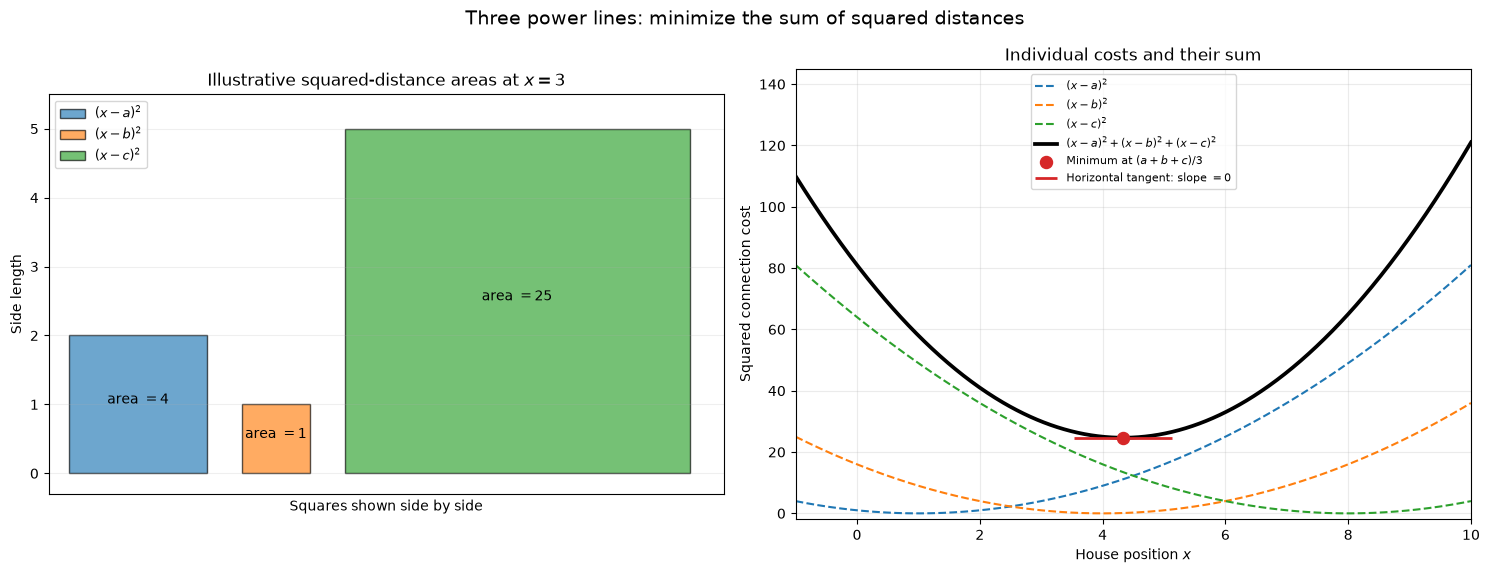

In [4]:
three_line_a: float = 1.0
three_line_b: float = 4.0
three_line_c: float = 8.0
three_line_mean: float = (three_line_a + three_line_b + three_line_c) / 3.0
three_line_house_example: float = 3.0
three_line_coordinates: np.ndarray = np.array([three_line_a, three_line_b, three_line_c])
three_line_distances: np.ndarray = np.abs(three_line_house_example - three_line_coordinates)
three_line_plot_positions: np.ndarray = np.linspace(-1.0, 10.0, 600)
three_line_blue_cost: np.ndarray = (three_line_plot_positions - three_line_a) ** 2
three_line_orange_cost: np.ndarray = (three_line_plot_positions - three_line_b) ** 2
three_line_green_cost: np.ndarray = (three_line_plot_positions - three_line_c) ** 2
three_line_total_cost: np.ndarray = (
    three_line_blue_cost + three_line_orange_cost + three_line_green_cost
)
three_line_minimum_cost: float = (
    (three_line_mean - three_line_a) ** 2
    + (three_line_mean - three_line_b) ** 2
    + (three_line_mean - three_line_c) ** 2
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
square_colors: list[str] = ["tab:blue", "tab:orange", "tab:green"]
square_labels: list[str] = ["$(x-a)^2$", "$(x-b)^2$", "$(x-c)^2$"]
square_offset: float = 0.0

for distance, color, label in zip(
    three_line_distances, square_colors, square_labels, strict=True
):
    area_square = Rectangle((square_offset, 0), distance, distance, facecolor=color,
                            alpha=0.65, edgecolor="black", label=label)
    axes[0].add_patch(area_square)
    axes[0].annotate(rf"area $={distance**2:g}$",
                     (square_offset + distance / 2, distance / 2), ha="center")
    square_offset += distance + 0.5

axes[0].set(
    title="Illustrative squared-distance areas at $x=3$",
    xlabel="Squares shown side by side",
    ylabel="Side length",
    xlim=(-0.3, square_offset),
    ylim=(-0.3, float(three_line_distances.max()) + 0.5),
    xticks=[],
)
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=9)

axes[1].plot(three_line_plot_positions, three_line_blue_cost, color="tab:blue",
             linestyle="--", label="$(x-a)^2$")
axes[1].plot(three_line_plot_positions, three_line_orange_cost, color="tab:orange",
             linestyle="--", label="$(x-b)^2$")
axes[1].plot(three_line_plot_positions, three_line_green_cost, color="tab:green",
             linestyle="--", label="$(x-c)^2$")
axes[1].plot(three_line_plot_positions, three_line_total_cost, color="black", linewidth=2.7,
             label="$(x-a)^2+(x-b)^2+(x-c)^2$")
axes[1].scatter([three_line_mean], [three_line_minimum_cost], color="tab:red", s=75,
                zorder=4, label="Minimum at $(a+b+c)/3$")
axes[1].hlines(three_line_minimum_cost, three_line_mean - 0.8, three_line_mean + 0.8,
               color="tab:red", linewidth=2, label="Horizontal tangent: slope $=0$")
axes[1].set(title="Individual costs and their sum", xlabel="House position $x$",
            ylabel="Squared connection cost", xlim=(-1, 10), ylim=(-2, 145))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle("Three power lines: minimize the sum of squared distances", fontsize=14)
fig.tight_layout()
plt.show()

### Differentiate each squared-distance term

At the minimum of the total-cost parabola, the tangent slope is zero:

$$
\frac{d}{dx}\left[(x-a)^2+(x-b)^2+(x-c)^2\right]=0.
$$

The sum rule lets us differentiate the three terms separately. For each shifted square, the chain rule includes an inner derivative equal to $1$ because $a$, $b$, and $c$ are constants:

$$
\begin{aligned}
\frac{d}{dx}(x-a)^2
&=2(x-a)\frac{d}{dx}(x-a)
=2(x-a)(1)
=2(x-a), \\
\frac{d}{dx}(x-b)^2
&=2(x-b)\frac{d}{dx}(x-b)
=2(x-b)(1)
=2(x-b), \\
\frac{d}{dx}(x-c)^2
&=2(x-c)\frac{d}{dx}(x-c)
=2(x-c)(1)
=2(x-c).
\end{aligned}
$$

Therefore,

$$
2(x-a)+2(x-b)+2(x-c)=0.
$$

### Solve for the optimal position

Divide both sides by $2$:

$$
(x-a)+(x-b)+(x-c)=0.
$$

Remove the parentheses and collect the three $x$ terms:

$$
\begin{aligned}
x-a+x-b+x-c&=0, \\
3x-a-b-c&=0, \\
3x&=a+b+c, \\
x&=\frac{a+b+c}{3}.
\end{aligned}
$$

Thus, the least-cost house position is the arithmetic mean of the three power-line coordinates:

$$
\boxed{x=\frac{a+b+c}{3}.}
$$

### Generalizing to $n$ power lines

Suppose $n$ power lines have coordinates

$$
a_1,a_2,\ldots,a_n.
$$

The total squared-distance cost is

$$
C(x)=\sum_{i=1}^{n}(x-a_i)^2.
$$

Setting its derivative equal to zero gives

$$
2\sum_{i=1}^{n}(x-a_i)=0.
$$

Since the sum contains $n$ copies of $x$,

$$
\begin{aligned}
nx-(a_1+a_2+\cdots+a_n)&=0, \\
x&=\frac{a_1+a_2+\cdots+a_n}{n}.
\end{aligned}
$$

Therefore, the value minimizing total squared distance is the arithmetic mean.

### Connection to squared loss

In machine learning, replace the power-line coordinates with target values $a_i$ and interpret $x$ as one constant prediction. Then

$$
\sum_{i=1}^{n}(x-a_i)^2
$$

is a sum of squared prediction errors.

The constant prediction that minimizes this squared loss is

$$
\boxed{x=\frac1n\sum_{i=1}^{n}a_i.}
$$

This is why the arithmetic mean naturally appears whenever squared error is minimized.

### Takeaway

For three power lines,

$$
C(x)=(x-a)^2+(x-b)^2+(x-c)^2
$$

is minimized at

$$
\boxed{x=\frac{a+b+c}{3}.}
$$

For any number of power lines—or target values—the same reasoning produces their arithmetic mean. The geometry of minimizing square areas and the machine-learning task of minimizing squared errors are the same mathematical pattern.

## Video 5 — From likelihood to log loss

Squared loss is one important machine-learning objective. Another is **log loss**, which is widely used for classification.

To introduce it, consider a game: a coin is tossed ten times, and the winning sequence is exactly seven heads followed by three tails. The order matters here; this is one specific sequence, not any ordering containing seven heads.

You may choose among three coins:

| Coin | Probability of heads | Probability of tails |
|---|---:|---:|
| 1 | $0.7$ | $0.3$ |
| 2 | $0.5$ | $0.5$ |
| 3 | $0.3$ | $0.7$ |

### Comparing the three coins

Coin tosses are treated as independent, so the probabilities of the ten required outcomes multiply.

For Coin 1,

$$
(0.7)^7(0.3)^3\approx0.00222.
$$

For Coin 2,

$$
(0.5)^7(0.5)^3=(0.5)^{10}\approx0.00098.
$$

For Coin 3,

$$
(0.3)^7(0.7)^3\approx0.00008.
$$

Coin 1 gives the largest probability among these three choices. Calculus can determine whether $0.7$ is also optimal among **all** possible head probabilities.

### The likelihood as a function of $p$

Let

$$
p=P(\text{heads}),
$$

so

$$
1-p=P(\text{tails}),
$$

with $0\le p\le1$.

The probability of the required sequence is

$$
\boxed{g(p)=p^7(1-p)^3.}
$$

When the observed outcomes are fixed and this probability is viewed as a function of the parameter $p$, it is called a **likelihood**. We want to choose $p$ that maximizes $g(p)$.

### Direct differentiation with the product rule

The likelihood is a product. Set

$$
u(p)=p^7
\qquad\text{and}\qquad
v(p)=(1-p)^3.
$$

The product rule gives

$$
g'(p)=u'(p)v(p)+u(p)v'(p).
$$

Differentiate the two factors:

$$
u'(p)=7p^6,
$$

and, using the chain rule,

$$
\begin{aligned}
v'(p)
&=3(1-p)^2\frac{d}{dp}(1-p) \\
&=3(1-p)^2(-1) \\
&=-3(1-p)^2.
\end{aligned}
$$

Therefore,

$$
g'(p)=7p^6(1-p)^3-3p^7(1-p)^2.
$$

### Factor and find the candidates

Both derivative terms contain $p^6(1-p)^2$. Factoring it out gives

$$
\begin{aligned}
g'(p)
&=p^6(1-p)^2\left[7(1-p)-3p\right] \\
&=p^6(1-p)^2(7-10p).
\end{aligned}
$$

Set the derivative equal to zero:

$$
p^6(1-p)^2(7-10p)=0.
$$

A product is zero when at least one factor is zero, producing three candidates:

$$
p=0,\qquad p=1,\qquad p=0.7.
$$

The endpoint values $p=0$ and $p=1$ make the required mixed sequence impossible, so $g(0)=g(1)=0$. The interior candidate $p=0.7$ gives the maximum likelihood.

### The logarithm makes the product easier

The natural logarithm is strictly increasing: if one positive number is larger than another, its logarithm is also larger. Therefore, maximizing $g(p)$ is equivalent to maximizing $\ln g(p)$ for $0<p<1$.

Define the **log-likelihood**

$$
G(p)=\ln g(p).
$$

Use the logarithm rules

$$
\ln(uv)=\ln u+\ln v
$$

and

$$
\ln(u^k)=k\ln u.
$$

Then

$$
\begin{aligned}
G(p)
&=\ln\left[p^7(1-p)^3\right] \\
&=\ln(p^7)+\ln((1-p)^3) \\
&=7\ln p+3\ln(1-p).
\end{aligned}
$$

The original product of ten probabilities has become a simple sum of two logarithmic terms.

### Optimize the log-likelihood

Differentiate each term. The second term needs the chain rule because $\ln$ is applied to $1-p$:

$$
\begin{aligned}
G'(p)
&=7\left(\frac1p\right)
 +3\left(\frac1{1-p}\right)\frac{d}{dp}(1-p) \\
&=\frac7p-\frac3{1-p}.
\end{aligned}
$$

Combine the fractions using the common denominator $p(1-p)$:

$$
\begin{aligned}
G'(p)
&=\frac{7(1-p)-3p}{p(1-p)} \\
&=\frac{7-10p}{p(1-p)}.
\end{aligned}
$$

Within $0<p<1$, the denominator is not zero. Thus, $G'(p)=0$ exactly when the numerator is zero:

$$
\begin{aligned}
7-10p&=0, \\
10p&=7, \\
p&=0.7.
\end{aligned}
$$

The logarithm route reaches the same optimum with simpler differentiation and algebra.

### From log-likelihood to log loss

For probabilities strictly between $0$ and $1$, their logarithms are negative. Machine-learning training is commonly written as a minimization problem, so we negate the log-likelihood:

$$
\boxed{L(p)=-G(p)=-7\ln p-3\ln(1-p).}
$$

This is the **negative log-likelihood**, or log loss, for the observed sequence. The optimization direction reverses:

$$
\text{maximize }G(p)
\quad\Longleftrightarrow\quad
\text{minimize }-G(p).
$$

Negating the function does not change the optimal $p$; it turns a maximum into a minimum.

### Probability, likelihood, and log loss

The plots below show three equivalent views of the same choice. The winning probability and log-likelihood are largest at $p=0.7$, while the negative log-likelihood is smallest there.

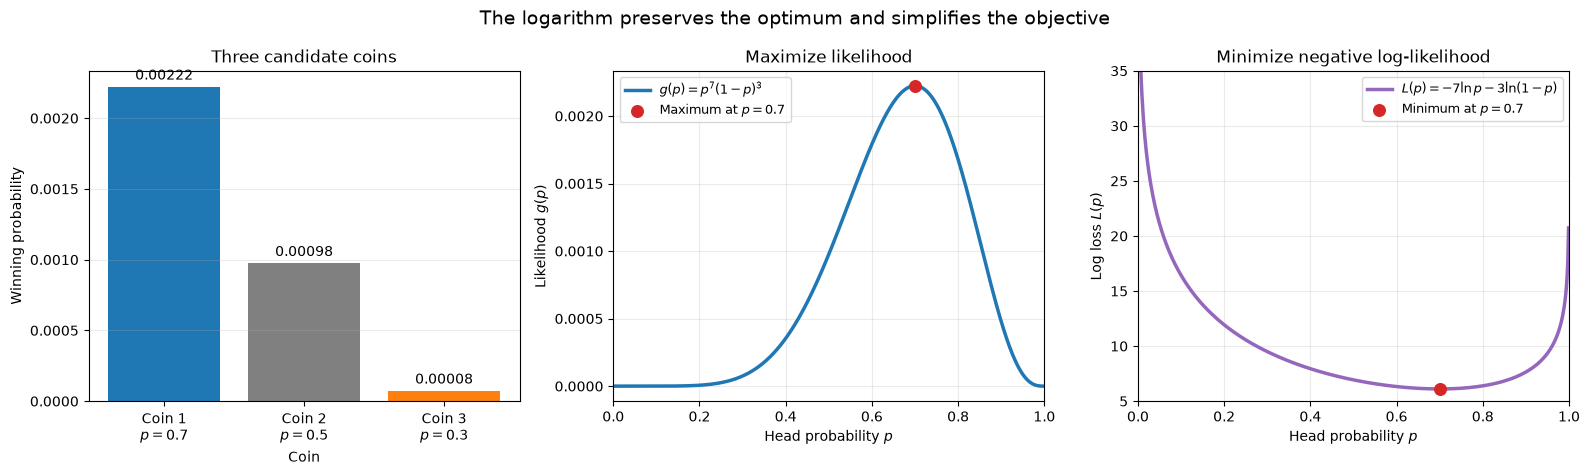

In [5]:
coin_head_probabilities: np.ndarray = np.array([0.7, 0.5, 0.3])
coin_sequence_probabilities: np.ndarray = (
    coin_head_probabilities**7 * (1.0 - coin_head_probabilities) ** 3
)
log_loss_probabilities: np.ndarray = np.linspace(0.001, 0.999, 600)
sequence_likelihoods: np.ndarray = (
    log_loss_probabilities**7 * (1.0 - log_loss_probabilities) ** 3
)
sequence_log_likelihoods: np.ndarray = (
    7.0 * np.log(log_loss_probabilities)
    + 3.0 * np.log(1.0 - log_loss_probabilities)
)
sequence_log_losses: np.ndarray = -sequence_log_likelihoods
optimal_head_probability: float = 0.7
optimal_sequence_probability: float = (
    optimal_head_probability**7 * (1.0 - optimal_head_probability) ** 3
)
optimal_log_loss: float = -float(np.log(optimal_sequence_probability))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].bar(["Coin 1\n$p=0.7$", "Coin 2\n$p=0.5$", "Coin 3\n$p=0.3$"],
            coin_sequence_probabilities, color=["tab:blue", "gray", "tab:orange"])
for coin_index, probability in enumerate(coin_sequence_probabilities):
    axes[0].annotate(f"{probability:.5f}", (coin_index, probability), ha="center",
                     xytext=(0, 5), textcoords="offset points")
axes[0].set(title="Three candidate coins", xlabel="Coin", ylabel="Winning probability")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(log_loss_probabilities, sequence_likelihoods, color="tab:blue", linewidth=2.5,
             label="$g(p)=p^7(1-p)^3$")
axes[1].scatter([optimal_head_probability], [optimal_sequence_probability], color="tab:red",
                s=70, zorder=3, label="Maximum at $p=0.7$")
axes[1].set(title="Maximize likelihood", xlabel="Head probability $p$",
            ylabel="Likelihood $g(p)$", xlim=(0, 1))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

axes[2].plot(log_loss_probabilities, sequence_log_losses, color="tab:purple", linewidth=2.5,
             label="$L(p)=-7\\ln p-3\\ln(1-p)$")
axes[2].scatter([optimal_head_probability], [optimal_log_loss], color="tab:red", s=70,
                zorder=3, label="Minimum at $p=0.7$")
axes[2].set(title="Minimize negative log-likelihood", xlabel="Head probability $p$",
            ylabel="Log loss $L(p)$", xlim=(0, 1), ylim=(5, 35))
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=9)

fig.suptitle("The logarithm preserves the optimum and simplifies the objective", fontsize=14)
fig.tight_layout()
plt.show()

### Takeaway

For seven heads and three tails,

$$
g(p)=p^7(1-p)^3
$$

is maximized at

$$
\boxed{p=0.7.}
$$

Taking a logarithm changes products into sums without changing which parameter maximizes the probability:

$$
G(p)=7\ln p+3\ln(1-p).
$$

Negating that log-likelihood produces the log loss

$$
L(p)=-7\ln p-3\ln(1-p),
$$

which is minimized at the same $p=0.7$. This maximize-likelihood/minimize-log-loss equivalence is a central pattern in classification.